# 11 — Colorado Performance Funding (HB 20-1366)

**Chapter 13 capstone.** Since FY 2021-22, Colorado has allocated most state
operating funding for its ten public governing boards through Step 2 of the
HB 20-1366 model. The model scores eight metrics, three of them outcome rates from
IPEDS. This notebook rebuilds the formula from public data, tests the rebuild
against what the legislature actually appropriated, and then asks what the formula
rewards.

| | |
|---|---|
| Inputs | `EF{y}D`, `EF{y}A`, `GR{y}` (2017-2024), `SFA` (2016-17 to 2023-24), `C{y}_A` (2018-2025); board funding and resident FTE from `dashboard/data/colorado.json` in the parent repository |
| Unit | Governing board (the formula's unit); institutions are aggregated to boards |
| Methods | Formula reconstruction, out-of-sample validation against appropriations, sensitivity analysis, counterfactual allocation, disaggregated completion gaps |
| Outputs | `reports/funding/fy2025_26_reconstruction.csv`, `reports/figures/11_*.png`, `dashboard/data/colorado_formula.json` (parent repository) |

**Policy boundary.** HB 20-1366 governs FY 2021-22 to FY 2026-27. HB 26-1345
([bill page](https://leg.colorado.gov/bills/hb26-1345)) replaces it from FY 2027-28
with "results-informed funding", which redefines the metrics and drops the
sequential Step 1-2-3 calculation. Nothing here describes the new model.

**Scope.** This is an institution- and board-level analysis. It does not score
students, and demographic fields are used only to describe group patterns.

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.2.0 | pandas 3.0.5 | numpy 2.5.3


## 1. Board funding and resident FTE

The parent repository's Colorado panel (`src/ingest/colorado.py`) already parses
each board's formula funding from Joint Budget Committee documents, with a page
citation per value, plus CDHE's resident FTE series. The notebook reads that file
rather than parsing the PDFs again. Outside the repository, it downloads the
same file from GitHub.

In [2]:
import json
import urllib.request

F = iu.funding
RAW = Path("../data/raw")
REPORTS = Path("../reports/funding")
REPORTS.mkdir(parents=True, exist_ok=True)

local = Path("../../dashboard/data/colorado.json")
remote = ("https://raw.githubusercontent.com/Adele-Labrador/postsecondary-ds-book/"
          "main/dashboard/data/colorado.json")
if local.exists():
    colorado = json.loads(local.read_text())
    print(f"read {local}")
else:
    cache = RAW / "colorado.json"
    if not cache.exists():
        RAW.mkdir(parents=True, exist_ok=True)
        cache.write_bytes(urllib.request.urlopen(remote, timeout=60).read())
    colorado = json.loads(cache.read_text())
    print(f"read {remote}")

state_boards = [b for b in colorado["boards"] if b["state"]]
fund = pd.DataFrame({b["id"]: b["funding"] for b in state_boards},
                    index=colorado["meta"]["fundingYears"]).T
fte = pd.DataFrame({b["id"]: b["fte"]["resident"] for b in state_boards},
                   index=colorado["meta"]["fteYears"]).T
names = {b["id"]: b["name"] for b in state_boards}
roster = pd.DataFrame([{k: i[k] for k in ("name", "board", "unitid")}
                       for i in colorado["institutions"]])
roster = roster[roster["board"].isin(fund.index)]
board_of = roster.groupby("unitid")["board"].first()
print(f"{len(fund)} governing boards, {board_of.size} IPEDS UNITIDs, "
      f"funding {fund.columns[0]} to {fund.columns[-1]}")
(fund[["FY 2023-24", "FY 2024-25", "FY 2025-26"]] / 1e6).round(1).assign(
    **{"FY 2025-26 change %": (fund["FY 2025-26"] / fund["FY 2024-25"] - 1) * 100})

read ../../dashboard/data/colorado.json
10 governing boards, 25 IPEDS UNITIDs, funding FY 2019-20 to FY 2025-26


,FY 2023-24,FY 2024-25,FY 2025-26,FY 2025-26 change %
CU,305.500,345.500,354.000,2.480
CSU,223.800,244.600,250.200,2.319
CCCS,269.100,292.600,299.800,2.470
MSU,93.200,102.200,105.700,3.365
UNC,63.100,68.900,70.500,2.248
CMU,44.700,48.900,50.000,2.364
CSM,33.600,37.100,38.100,2.930
FLC,19.000,23.100,23.800,2.796
WCU,20.200,24.700,25.200,2.032
ASU,23.500,28.000,28.600,1.983


The FY 2025-26 Long Bill provided a 2.5% increase, all of it through Step 2. Had
every board received exactly 2.5%, performance would have moved nothing. Instead,
increases range from 2.0% (Adams State) to 3.4% (MSU Denver). That spread is the
formula's output, and the target the reconstruction has to hit.

Several boards govern more than one campus. CU has four rows in CDHE's FTE reports and three
IPEDS UNITIDs, because Denver and Anschutz report to IPEDS together. Board-level
funding hides how each board divides money among its campuses.

## 2. The mechanics

For each metric and board, CDHE computes `D`, the four-year average divided by the
average of its three oldest years. It multiplies `D` by the board's share of
prior-year funding and renormalises. The weighted sum across metrics is the board's
Step 2 share. The first check reproduces the worked example in CDHE's
[data definitions](https://cdhe.colorado.gov/sites/highered/files/Colorado_Performance_Funding_Overview_and_Data_Definitions_2025_26_1.pdf).

In [3]:
prior = pd.Series([0.10, 0.20, 0.70], index=["Board X", "Board Y", "Board Z"])
d = pd.Series([105 / 100, 550 / 500, 910 / 900], index=prior.index)
example = pd.DataFrame({"A prior share": prior, "D": d, "F allocation": F.metric_allocation(prior, d)})
assert (example["F allocation"] * 100).round(1).tolist() == [10.2, 21.3, 68.5]
(example * 100).round(1)

,A prior share,D,F allocation
Board X,10.000,105.000,10.200
Board Y,20.000,110.000,21.300
Board Z,70.000,101.100,68.500


The example matches the published table to one decimal. Two properties of the
arithmetic matter for everything that follows.

First, `D = 0.75 + 0.25 × x₄ / mean(x₁, x₂, x₃)`. Only the newest year moves `D`,
and by a quarter of its change relative to the prior mean. Second, the reward for a
lasting improvement is front-loaded and then stops. A board that raises a metric 1%
and holds it there gains on that metric for three windows. After that, the higher
level is the baseline and `D` returns to 1. The cell below traces that path. The
gain does not disappear, though: it becomes part of the prior-year share that every
later allocation starts from.

In [4]:
def reward_path(step=0.01, windows=6):
    level = np.r_[np.ones(3), np.full(windows + 3, 1 + step)]
    return pd.Series([F.d_ratio(level[i:i + 4]) - 1 for i in range(windows)],
                     index=pd.RangeIndex(1, windows + 1, name="window after the step"))

path = (reward_path() * 100).rename("D - 1 (%) after a lasting 1% improvement")
print(path.round(3).to_string())
print(f"cumulative D - 1 over all windows: {path.sum():.3f}%")

window after the step
1   0.250
2   0.166
3   0.083
4   0.000
5   0.000
6   0.000
cumulative D - 1 over all windows: 0.499%


A lasting 1% improvement raises `D` by 0.25%, then 0.17%, then 0.08%, then
nothing: half of the improvement, spread over three years. Because each board's
allocation is renormalised against all the others, what counts is improving faster
than the other boards, not improving at all.

## 3. What IPEDS can and cannot rebuild

Only half of the Step 2 weight can be measured from data the formula actually uses.
Retention and the two graduation rates come from IPEDS for every board except eight
CCCS colleges. Resident FTE comes from the same CDHE series the formula uses. The
other four metrics come from SURDS, the state's student-unit records, which are not
public. IPEDS proxies stand in for three of them. First-generation status has no
IPEDS equivalent, so that metric is held neutral, which leaves every board's
allocation on it equal to its prior share.

In [5]:
fidelity = pd.DataFrame(F.METRICS).T.assign(weight=pd.Series(F.WEIGHTS))
fidelity[["label", "weight", "fidelity", "proxy"]].sort_values("weight", ascending=False)

,label,weight,fidelity,proxy
pell_share,Resident Pell-eligible share,0.200,proxy,IPEDS SFA UPGRNTN / SCUGRAD: Pell recipients a...
urm_share,Resident underrepresented minority share,0.200,proxy,IPEDS EF_A (EFALEVEL 1): Black + Hispanic + AI...
retention,Retention rate,0.200,same source (except eight CCCS colleges),IPEDS EF_D RET_NMF / RRFTCTA
resident_fte,Resident FTE enrollment,0.100,same source,"Same CDHE series (hed1540), read from dashboar..."
grad100,100% graduation rate,0.100,same source (except eight CCCS colleges),IPEDS GR GRTYPE 13/8 (4-year) or 35/29 (2-year)
grad150,150% graduation rate,0.100,same source (except eight CCCS colleges),IPEDS GR GRTYPE 12/8 (4-year) or 30/29 (2-year)
credentials,Resident credential completion,0.050,proxy,"IPEDS C_A, CIP 99 first-major totals; all stud..."
first_gen,Resident first-generation UG headcount,0.050,not available (held neutral),None: IPEDS does not collect first-generation ...


## 4. Build the metric panel from IPEDS

Every file is checked against its own dictionary before use. The fall surveys must
read "Fall {y}". The GR files must name their 4-year cohort year, because GR mixes
two cohorts in one file (four-year institutions six years back, two-year
institutions three years back). The SFA aid year and the Completions award year are
checked the same way. The panel is long: one row per institution, metric, and year,
with a numerator, a denominator, and the cohort definition used (`src`).

In [6]:
U = board_of.index


def load(table, expect, cols=None):
    record = iu.fetch(table, raw_dir=RAW)
    iu.assert_reference_period(record["dict_path"], expect=expect, table=table)
    frame = iu.read_csv(record["data_path"], usecols=cols)
    return frame[frame["UNITID"].isin(U)]


rows = []
for y in range(2017, 2025):
    ef = load(f"EF{y}D", f"Fall {y}", ["UNITID", "RRFTCTA", "RET_NMF"])
    rows += [dict(UNITID=r.UNITID, metric="retention", year=y, num=r.RET_NMF, den=r.RRFTCTA)
             for r in ef.itertuples()]

    # GR2024's provisional dictionary title still says "cohort year 2017"; its
    # overview sentence ("students who were enrolled in 2018") is the reliable anchor.
    gr = load(f"GR{y}", rf"bachelor.{{0,40}}enrolled in {y - 6}", ["UNITID", "GRTYPE", "GRTOTLT"])
    gr = gr.pivot_table(index="UNITID", columns="GRTYPE", values="GRTOTLT", aggfunc="sum")
    for unitid, g in gr.iterrows():
        if pd.notna(g.get(8)):       # bachelor's subcohort at a four-year institution
            spec = ("BA subcohort", g[8], g.get(13), g.get(12))
        elif pd.notna(g.get(29)):    # degree/certificate cohort at a two-year institution
            spec = ("2-yr cohort", g[29], g.get(35), g.get(30))
        elif pd.notna(g.get(2)):     # four-year institution with no bachelor's subcohort
            spec = ("4-yr total cohort", g[2], np.nan, g.get(3))
        else:
            continue
        src, cohort, on_time, within_150 = spec
        rows.append(dict(UNITID=unitid, metric="grad100", year=y, num=on_time, den=cohort, src=src))
        rows.append(dict(UNITID=unitid, metric="grad150", year=y, num=within_150, den=cohort, src=src))

    ea = load(f"EF{y}A", f"Fall {y}")
    ea = ea[ea["EFALEVEL"] == 1]
    rows += [dict(UNITID=r.UNITID, metric="urm_share", year=y,
                  num=r.EFBKAAT + r.EFHISPT + r.EFAIANT, den=r.EFTOTLT - r.EFNRALT)
             for r in ea.itertuples()]

for y in range(2016, 2025):  # SFA aid year y-(y+1) stands for fall y
    table = f"SFA{y % 100:02d}{(y + 1) % 100:02d}"
    try:
        sfa = load(table, f"{y}-{(y + 1) % 100:02d}", ["UNITID", "UPGRNTN", "SCUGRAD"])
    except iu.FetchError:
        print(f"{table} not published yet: fall {y} Pell share unavailable")
        continue
    rows += [dict(UNITID=r.UNITID, metric="pell_share", year=y, num=r.UPGRNTN, den=r.SCUGRAD)
             for r in sfa.itertuples()]

for y in range(2018, 2026):
    c = load(f"C{y}_A", f"July 1, {y - 1} and June 30, {y}",
             ["UNITID", "CIPCODE", "MAJORNUM", "CTOTALT"])
    c = c[(c["CIPCODE"] == "99") & (c["MAJORNUM"] == 1)]
    rows += [dict(UNITID=u, metric="credentials", year=y, num=v, den=np.nan)
             for u, v in c.groupby("UNITID")["CTOTALT"].sum().items()]

panel = pd.DataFrame(rows)
panel["board"] = panel["UNITID"].map(board_of)
panel["src"] = panel["src"].fillna("")
panel.groupby(["metric", "year"])["UNITID"].nunique().unstack("metric")

SFA2425 not published yet: fall 2024 Pell share unavailable


metric,credentials,grad100,grad150,pell_share,retention,urm_share
year,,,,,,
2016,NaN,NaN,NaN,25.000,NaN,NaN
2017,NaN,25.000,25.000,25.000,25.000,25.000
2018,25.000,25.000,25.000,25.000,25.000,25.000
2019,25.000,25.000,25.000,25.000,25.000,25.000
2020,25.000,25.000,25.000,25.000,25.000,25.000
2021,25.000,25.000,25.000,25.000,25.000,25.000
2022,25.000,25.000,25.000,25.000,25.000,25.000
2023,25.000,25.000,25.000,25.000,25.000,25.000
2024,25.000,25.000,25.000,NaN,25.000,25.000


## 5. The reclassification trap

Eight CCCS colleges began awarding bachelor's degrees, and IPEDS reclassified them
as four-year institutions. At a four-year institution, IPEDS counts only
bachelor's seekers in the retention cohort and reports no 100%-time rate for
associate seekers. The cohort an IPEDS-based formula would read collapses.

In [7]:
names_hd = iu.read_csv(iu.fetch("HD2023", raw_dir=RAW)["data_path"], usecols=["UNITID", "INSTNM"])
instnm = names_hd.set_index("UNITID")["INSTNM"]
cccs = panel[(panel["board"] == "CCCS") & (panel["metric"] == "retention")]
trap = cccs.pivot_table(index="UNITID", columns="year", values="den").rename(index=instnm)
trap.astype("Int64").sort_values(2017, ascending=False)

year,2017,2018,2019,2020,2021,2022,2023,2024
UNITID,,,,,,,,
Front Range Community College,1099,1065,0,0,0,0,0,1
Pikes Peak State College,1052,0,0,0,0,0,0,0
Red Rocks Community College,521,0,0,0,4,7,4,0
Community College of Denver,430,0,0,0,0,0,0,0
Northeastern Junior College,429,413,375,365,280,347,278,274
Arapahoe Community College,405,0,0,474,0,0,0,0
Community College of Aurora,308,403,337,398,274,260,264,320
Trinidad State College,240,271,222,247,260,254,212,271
Pueblo Community College,233,0,0,0,0,2,0,2


In [8]:
totals = trap.sum()
print(f"CCCS full-time retention cohort in IPEDS: {totals[2017]:,.0f} students (fall 2016 entrants) "
      f"-> {totals[2023]:,.0f} (fall 2022 entrants) -> {totals[2024]:,.0f} (fall 2023 entrants)")

CCCS full-time retention cohort in IPEDS: 5,384 students (fall 2016 entrants) -> 1,207 (fall 2022 entrants) -> 1,223 (fall 2023 entrants)


Front Range's retention cohort falls from about 1,100 students to zero, and Pikes
Peak's from about 1,050. Across CCCS, the IPEDS cohort shrinks by about three
quarters (5,384 to 1,207 students), almost all of it because of how these colleges are classified, not because
fewer students enrolled. CDHE computes these colleges' rates from SURDS, following
IPEDS methodology, which is why the
[FY 2026-27 JBC briefing](https://content.leg.colorado.gov/sites/default/files/fy2026-27_hedbrf.pdf)
recommends SURDS for all institutions.

The reconstruction keeps an institution in a metric only if it reports under one
definition, with a positive cohort, in every year of the window
(`iu.funding.consistent_reporters`). For CCCS this means the rates rest on the
colleges that never changed classification. The rate's level is then
unrepresentative, but its change over the window is still measured within the same
colleges.

## 6. Reconstruct FY 2025-26

CDHE documents the FY 2024-25 windows (fall 2019 to fall 2022, GR cohorts ending in
the GR2022 release, credentials through 2022-23) and states that the FY 2025-26
graduation rates start from the fall 2017 cohort. FY 2025-26 is therefore fall 2020
to fall 2023, which `F.formula_window` encodes. The prior share is each board's
share of FY 2024-25 funding. SFA 2023-24, released on NCES's new download path in
2026, completes the Pell window, so every metric uses its documented years. The
2023 files are NCES's revised releases.

In [9]:
def board_d(fy_start, *, how="pooled", shift=0, drop=(), data=None):
    data = panel if data is None else data
    d = pd.DataFrame(index=fund.index)
    notes = {}
    for metric in ["retention", "grad100", "grad150", "urm_share", "pell_share", "credentials"]:
        if metric in drop:
            continue
        years = [y + shift for y in F.formula_window(fy_start, metric)]
        sub = data[data["metric"] == metric]
        if years[-1] > sub["year"].max():           # newest year not yet published
            years = [y - 1 for y in years]
            notes[metric] = f"window shifted back to {years[0]}-{years[-1]}"
        series = F.board_series(sub, years, how=how)
        d[metric] = series.apply(F.d_ratio, axis=1)
        notes.setdefault(metric, f"{years[0]}-{years[-1]}, {F.consistent_reporters(sub, years).size} institutions")
    if "resident_fte" not in drop:
        fy = [F.fiscal_year_label(y + shift) for y in F.formula_window(fy_start, "resident_fte")]
        d["resident_fte"] = fte[fy].apply(F.d_ratio, axis=1)
        notes["resident_fte"] = f"{fy[0]} to {fy[-1]} (CDHE)"
    return d, notes


def predict(fy_start, **kw):
    base = fund[F.fiscal_year_label(fy_start - 1)]
    new = fund[F.fiscal_year_label(fy_start)]
    d, notes = board_d(fy_start, **kw)
    shares = F.step2_shares(base, d)
    return (shares * new.sum() / base - 1) * 100, d, notes


T = 2025
actual = (fund[F.fiscal_year_label(T)] / fund[F.fiscal_year_label(T - 1)] - 1) * 100
pred, D, notes = predict(T)
print(pd.Series(notes).to_string())
D.round(4)

retention            2020-2023, 18 institutions
grad100              2020-2023, 17 institutions
grad150              2020-2023, 24 institutions
urm_share            2020-2023, 25 institutions
pell_share           2020-2023, 25 institutions
credentials          2021-2024, 25 institutions
resident_fte    FY 2020-21 to FY 2023-24 (CDHE)


,retention,grad100,grad150,urm_share,pell_share,credentials,resident_fte
CU,1.004,1.024,1.004,1.010,0.996,0.999,0.997
CSU,0.999,1.006,0.998,1.013,1.001,1.009,0.998
CCCS,1.022,1.009,1.021,1.010,0.970,1.007,1.023
MSU,1.033,1.048,0.997,1.026,1.014,1.006,0.984
UNC,1.010,1.013,0.998,1.030,0.999,0.966,0.974
CMU,1.003,1.013,1.015,0.997,0.988,1.075,1.010
CSM,1.002,1.001,0.991,1.031,1.002,1.018,1.012
FLC,1.008,1.014,1.009,0.979,0.988,0.991,1.020
WCU,1.001,1.015,1.012,1.011,0.953,0.981,1.009
ASU,0.987,0.964,0.956,0.993,1.013,1.003,1.019


correlation 0.82; RMSE 0.45 percentage points; spread of actual increases 1.98% to 3.36%


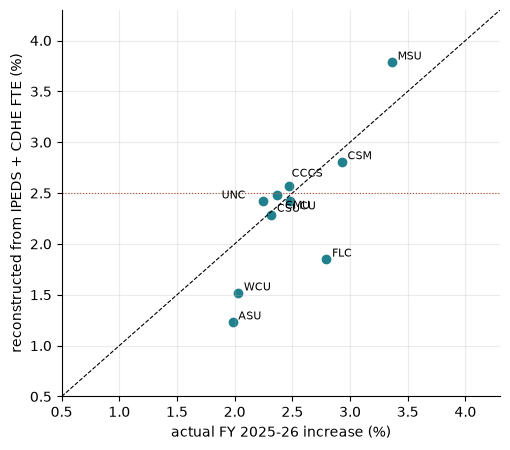

,actual %,reconstructed %,error (pts)
CU,2.480,2.420,-0.060
CSU,2.320,2.290,-0.030
CCCS,2.470,2.570,0.090
MSU,3.360,3.790,0.420
UNC,2.250,2.420,0.170
CMU,2.360,2.480,0.120
CSM,2.930,2.800,-0.130
FLC,2.800,1.850,-0.950
WCU,2.030,1.520,-0.520
ASU,1.980,1.230,-0.750


In [10]:
result = pd.DataFrame({"actual %": actual, "reconstructed %": pred})
result["error (pts)"] = result["reconstructed %"] - result["actual %"]
r = np.corrcoef(result["actual %"], result["reconstructed %"])[0, 1]
rmse = np.sqrt((result["error (pts)"] ** 2).mean())
print(f"correlation {r:.2f}; RMSE {rmse:.2f} percentage points; "
      f"spread of actual increases {actual.min():.2f}% to {actual.max():.2f}%")
result.assign(board=pd.Series(names)).to_csv(REPORTS / "fy2025_26_reconstruction.csv")

fig, ax = plt.subplots(figsize=(5.2, 4.6))
ax.scatter(result["actual %"], result["reconstructed %"], color="#20808D")
offsets = {"CCCS": (2, 7), "CU": (7, -6), "UNC": (-30, 2), "CMU": (6, -10)}
for b, row in result.iterrows():
    ax.annotate(b, (row["actual %"], row["reconstructed %"]), xytext=offsets.get(b, (4, 2)),
                textcoords="offset points", fontsize=8)
lim = [0.5, 4.3]
ax.plot(lim, lim, color="k", lw=0.8, ls="--")
ax.axhline(2.5, color="#A84B2F", lw=0.8, ls=":")
ax.set(xlim=lim, ylim=lim, xlabel="actual FY 2025-26 increase (%)",
       ylabel="reconstructed from IPEDS + CDHE FTE (%)")
save("11_reconstruction_fy2025_26")
result.round(2)

The reconstruction tracks the pattern of actual increases (correlation 0.82, RMSE
0.45 points) using only public data, with half the weight measured by proxies. It
places MSU Denver first and Adams State last, as the Long Bill did. The largest
errors are at the three smallest boards, all understated: Fort Lewis by about 0.95
points, Adams State by 0.75 and Western by 0.5. MSU Denver's gain is overstated by
about 0.4. Small cohorts make IPEDS rates noisy. Adams State's graduation rates also
fall sharply in the window (`D` about 0.96 for both), and its prior share includes
the FY 2024-25 Step 1 money. Either the SURDS metrics moved in these boards' favour,
or an adjustment outside Step 2 is involved. The public data cannot say which.

### Is the fit an accident?

A reconstruction with this many choices can fit by luck. The next cell varies one
choice at a time: shifting every window back a year, averaging institution rates
instead of pooling counts, and dropping the proxy metrics.

In [11]:
variants = {
    "documented windows (baseline)": {},
    "every window one year earlier": {"shift": -1},
    "mean of institution rates": {"how": "mean"},
    "Pell proxy held neutral": {"drop": ("pell_share",)},
    "Pell and URM proxies neutral": {"drop": ("pell_share", "urm_share")},
    "IPEDS rates only (+FTE neutral)": {"drop": ("pell_share", "urm_share", "credentials", "resident_fte")},
    "resident FTE only": {"drop": ("pell_share", "urm_share", "credentials", "retention", "grad100", "grad150")},
}
rows = []
for label, kw in variants.items():
    p, _, _ = predict(T, **kw)
    rows.append({"variant": label, "correlation": np.corrcoef(actual, p)[0, 1],
                 "RMSE (pts)": np.sqrt(((p - actual) ** 2).mean()),
                 "ASU": p["ASU"], "MSU": p["MSU"]})
pd.DataFrame(rows).set_index("variant").round(2)

,correlation,RMSE (pts),ASU,MSU
variant,,,,
documented windows (baseline),0.820,0.450,1.230,3.790
every window one year earlier,-0.000,0.610,2.440,2.870
mean of institution rates,0.830,0.450,1.270,3.830
Pell proxy held neutral,0.640,0.530,0.790,3.320
Pell and URM proxies neutral,0.590,0.460,1.180,3.040
IPEDS rates only (+FTE neutral),0.610,0.460,1.030,3.220
resident FTE only,-0.200,0.460,2.660,2.310


Shifting the windows by one year drops the correlation from 0.82 to zero, so the
documented windows carry real information and the fit is not generic. Pooling
counts and averaging rates give almost the same answer. Each proxy that is
neutralised lowers the correlation, which suggests the proxies carry some of the
signal SURDS provides, imperfectly. FTE alone is slightly negatively related to the actual pattern.
Under this model, enrollment change was not what drove FY 2025-26.

**FY 2024-25 is not a clean second test.** The FY 2023-24 and FY 2024-25 amounts
come from different JBC documents, and CU's increase (13.1%, against a 10.3% pool)
is larger than any Step 2 reallocation could produce. Both points suggest a
non-formula adjustment, so that year is not used for validation.

## 7. How much money does performance move?

The formula re-divides the whole base every year, which sounds like a lot of
money at stake. The counterfactual is a uniform 2.5% increase.

In [12]:
moved = F.redistribution(fund["FY 2024-25"], fund["FY 2025-26"])
total = moved["moved"].clip(lower=0).sum()
print(f"FY 2025-26 Step 2 total ${moved['actual'].sum() / 1e6:,.1f}M; moved relative to a "
      f"uniform increase ${total / 1e6:.2f}M ({total / moved['actual'].sum():.3%} of the total)")

# FY 2026-27 request, 'FY 2026-27 Step 2 Formula Adjust' column (JBC briefing, HED-brf 35)
request = pd.Series({"ASU": -534_929, "CMU": 421_481, "MSU": -248_931, "WCU": -291_005,
                     "CSU": 88_169, "FLC": -410_724, "CU": 385_481, "CSM": 336_094,
                     "UNC": 31_334, "CCCS": 223_031})
print(f"FY 2026-27 request: Step 2 formula adjustments net to ${request.sum():,}; "
      f"${request.clip(lower=0).sum() / 1e6:.2f}M moves between boards")
(moved.assign(**{"FY 2026-27 request adj.": request})[["actual_pct", "moved", "FY 2026-27 request adj."]]
 .rename(columns={"actual_pct": "FY 2025-26 %", "moved": "FY 2025-26 moved ($)"})
 .round(2))

FY 2025-26 Step 2 total $1,245.9M; moved relative to a uniform increase $1.11M (0.089% of the total)
FY 2026-27 request: Step 2 formula adjustments net to $1; $1.49M moves between boards


,FY 2025-26 %,FY 2025-26 moved ($),FY 2026-27 request adj.
CU,2.480,"-71,377.780",385481
CSU,2.320,"-446,640.590",88169
CCCS,2.470,"-89,912.740",223031
MSU,3.360,"882,841.140",-248931
UNC,2.250,"-174,294.070",31334
CMU,2.360,"-66,862.280",421481
CSM,2.930,"158,955.540",336094
FLC,2.800,"68,171.280",-410724
WCU,2.030,"-115,852.230",-291005
ASU,1.980,"-145,028.270",-534929


About $1.1 million moved between boards in FY 2025-26, under 0.1% of a $1.25 billion
allocation. The FY 2026-27 request moves about $1.5 million. The formula re-divides
the whole base each year, but the prior-year share anchors almost all of it, and
`D` ratios close to one move little. The result is stability, and a small
incentive at the margin.

### A second test: the FY 2026-27 request

The fall 2024 IPEDS files are now available, so the same code can rebuild
FY 2026-27, a year the reconstruction was not tuned on. The Long Bill adds no new
state funding that year, so Step 2 only re-divides the FY 2025-26 base. The test
compares the rebuilt reallocation with the request's "Step 2 Formula Adjust"
column from the [FY 2026-27 JBC briefing](https://content.leg.colorado.gov/sites/default/files/fy2026-27_hedbrf.pdf).
The prior share is each board's FY 2025-26 share. SFA 2024-25 is not yet
published, so the Pell proxy runs one year behind the formula; the cell output
flags this.

In [13]:
T2 = 2026
base2 = fund[F.fiscal_year_label(T2 - 1)]
D2, notes2 = board_d(T2)
rebuilt = (F.step2_shares(base2, D2) - base2 / base2.sum()) * base2.sum()
D2_shift, _ = board_d(T2, shift=-1)
shifted = (F.step2_shares(base2, D2_shift) - base2 / base2.sum()) * base2.sum()

test2 = pd.DataFrame({"rebuilt ($)": rebuilt, "request ($)": request, "windows one year earlier ($)": shifted})
r2 = np.corrcoef(test2["rebuilt ($)"], test2["request ($)"])[0, 1]
r2_shift = np.corrcoef(test2["windows one year earlier ($)"], test2["request ($)"])[0, 1]
agree2 = int((np.sign(test2["rebuilt ($)"]) == np.sign(test2["request ($)"])).sum())
print(pd.Series(notes2).to_string())
print(f"correlation with the request {r2:.2f} (windows one year earlier: {r2_shift:.2f}); "
      f"signs agree on {agree2} of 10 boards; moved ${rebuilt.clip(lower=0).sum():,.0f} rebuilt vs "
      f"${request.clip(lower=0).sum():,.0f} requested")
test2.round(0)

retention             2021-2024, 17 institutions
grad100               2021-2024, 16 institutions
grad150               2021-2024, 24 institutions
urm_share             2021-2024, 25 institutions
pell_share      window shifted back to 2020-2023
credentials           2022-2025, 25 institutions
resident_fte     FY 2021-22 to FY 2024-25 (CDHE)
correlation with the request 0.63 (windows one year earlier: -0.05); signs agree on 8 of 10 boards; moved $1,194,986 rebuilt vs $1,485,590 requested


,rebuilt ($),request ($),windows one year earlier ($)
ASU,"-289,842.000",-534929,"-354,553.000"
CCCS,"77,152.000",223031,"184,069.000"
CMU,"204,219.000",421481,"-9,834.000"
CSM,"237,171.000",336094,"112,573.000"
CSU,"361,898.000",88169,"-522,406.000"
CU,"9,481.000",385481,"-280,700.000"
FLC,"-370,982.000",-410724,"-151,720.000"
MSU,"305,066.000",-248931,"1,322,173.000"
UNC,"-95,265.000",31334,"-57,205.000"
WCU,"-438,898.000",-291005,"-242,397.000"


The rebuilt FY 2026-27 reallocation correlates 0.63 with the request, and the signs
agree on eight of ten boards. It moves $1.19 million between boards against the
request's $1.49 million. Shifting every window back a year destroys the fit
(correlation -0.05), as it did for FY 2025-26, so the documented windows carry the
signal in a year the model was not tuned on. The two sign misses are MSU Denver,
rebuilt to gain about $305,000 where the request takes $249,000, and UNC, a small
loss where the request gives a small gain. CU is close to zero here but gains
$385,000 in the request.

The fit is weaker than FY 2025-26's, for three visible reasons. Dollar adjustments
magnify small differences in `D` that percentage increases hide. The Pell window lags
a year. And Colorado Northwestern reports no full-time retention cohort for fall
2023, so only five CCCS colleges remain in the IPEDS retention window. The request
is also a request: the appropriation can differ, and CDHE can still revise the
SURDS inputs.

### How strong is the fit?

Ten boards is a small sample, so a correlation of 0.6 or 0.8 could arise by chance,
and a single board can carry it. The cells below give five checks for both years:

1. **Exact permutation test.** Every one of the 10! = 3,628,800 ways of assigning
   the actual (or requested) changes to boards, counting how often the correlation
   is at least as high as observed. This needs no distributional assumption.
2. **Confidence intervals** for the correlation: Fisher's z, and a percentile
   bootstrap that resamples boards. With n = 10 both are wide, and the bootstrap
   is only a rough guide.
3. **Leave one board out**, to see whether any single board makes the fit.
4. **Placebo windows.** The same formula run on windows one, two and three years
   too early. If the fit is real, the documented windows should beat all of them.
5. **Cohort noise.** Retention and graduation rates come from finite cohorts, so
   a board's rate would vary from cohort to cohort even if nothing changed. The
   simulation redraws every institution-year's retained and graduated counts as
   binomial with the observed rate and rebuilds the reconstruction 2,000 times.
   The enrollment shares, credentials and FTE are administrative counts and are
   held fixed. The result is an interval for each board's predicted change.

In [14]:
from itertools import islice, permutations

base25 = fund[F.fiscal_year_label(T - 1)]
target25 = actual.reindex(fund.index)
target26 = request.reindex(fund.index).astype(float)


def fit25(d):
    return (F.step2_shares(base25, d) * fund[F.fiscal_year_label(T)].sum() / base25 - 1) * 100


def fit26(d):
    return (F.step2_shares(base2, d) - base2 / base2.sum()) * base2.sum()


def r_of(x, y):
    return float(np.corrcoef(x, y)[0, 1])


def exact_perm_p(x, y, chunk=400_000):
    # Share of all 10! board assignments with a correlation at least as high.
    x = (x - x.mean()) / x.std(ddof=0)
    y = np.asarray((y - y.mean()) / y.std(ddof=0))
    obs = float(x @ y) / len(x)
    hits = total = 0
    perms = permutations(range(len(y)))
    while True:
        block = np.fromiter((i for p in islice(perms, chunk) for i in p), dtype=np.int8)
        if block.size == 0:
            break
        r = (y[block.reshape(-1, len(y))] @ np.asarray(x)) / len(x)
        hits += int((r >= obs - 1e-12).sum())
        total += len(r)
    return hits / total, total


rng = np.random.default_rng(1366)
years_fit = {
    "FY 2025-26 vs actual": (fit25(D), target25, fit25, T),
    "FY 2026-27 vs request": (fit26(D2), target26, fit26, T2),
}
rows, strength_num = [], {}
for label, (pred_x, y, fn, fy) in years_fit.items():
    r = r_of(pred_x, y)
    p_perm, n_perm = exact_perm_p(pred_x, y)
    z, se = np.arctanh(r), 1 / np.sqrt(len(y) - 3)
    boot = []
    for _ in range(10_000):
        idx = rng.integers(0, len(y), len(y))
        if np.unique(idx).size > 2:
            boot.append(r_of(pred_x.iloc[idx], y.iloc[idx]))
    loo = [r_of(pred_x.drop(b), y.drop(b)) for b in y.index]
    placebo = [r_of(fn(board_d(fy, shift=-k)[0]), y) for k in (1, 2, 3)]
    strength_num[fy] = {
        "r": r, "p": p_perm, "permutations": n_perm,
        "fisher": [float(np.tanh(z - 1.96 * se)), float(np.tanh(z + 1.96 * se))],
        "bootstrap": [float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))],
        "leaveOneOut": dict(zip(y.index, loo)), "placebo": placebo,
    }
    rows.append({
        "fit": label, "r": r, "exact permutation p": p_perm,
        "Fisher 95% CI": f"{np.tanh(z - 1.96 * se):.2f} to {np.tanh(z + 1.96 * se):.2f}",
        "bootstrap 95% CI": f"{np.percentile(boot, 2.5):.2f} to {np.percentile(boot, 97.5):.2f}",
        "leave-one-out r": f"{min(loo):.2f} to {max(loo):.2f} (without {y.index[int(np.argmin(loo))]}: lowest)",
        "placebo r (1, 2, 3 yrs early)": ", ".join(f"{v:.2f}" for v in placebo),
    })
print(f"permutations checked per year: {n_perm:,}")
strength = pd.DataFrame(rows).set_index("fit")
strength.round(4).T

permutations checked per year: 3,628,800


fit,FY 2025-26 vs actual,FY 2026-27 vs request
r,0.820,0.632
exact permutation p,0.003,0.028
Fisher 95% CI,0.39 to 0.96,0.00 to 0.90
bootstrap 95% CI,0.11 to 0.97,0.01 to 0.94
leave-one-out r,0.63 to 0.93 (without MSU: lowest),0.55 to 0.81 (without FLC: lowest)
"placebo r (1, 2, 3 yrs early)","-0.00, -0.28, 0.43","-0.05, 0.01, -0.20"


In [15]:
RATES = ["retention", "grad100", "grad150"]
boards_idx = {b: k for k, b in enumerate(fund.index)}


def rate_spec(fy, metric):
    # Rows a board's pooled rate uses (consistent reporters, window years), with
    # a board-by-year group id. Redrawing counts never changes a cohort size or a
    # reporter, so the grouping is fixed across draws.
    sub = panel[panel["metric"] == metric]
    yrs = F.formula_window(fy, metric)
    rows = sub[sub["UNITID"].isin(F.consistent_reporters(sub, yrs)) & sub["year"].isin(yrs)]
    group = rows["board"].map(boards_idx).to_numpy() * 4 + rows["year"].map({y: k for k, y in enumerate(yrs)}).to_numpy()
    den = np.bincount(group, rows["den"].to_numpy(dtype=float), minlength=4 * len(fund))
    return rows.index.to_numpy(), group, den


rate_rows = panel[panel["metric"].isin(RATES) & (panel["den"] > 0) & panel["num"].notna()]
n_obs = rate_rows["den"].astype(int).to_numpy()
p_obs = (rate_rows["num"] / rate_rows["den"]).clip(0, 1).to_numpy(dtype=float)
pos = pd.Series(np.arange(len(rate_rows)), index=rate_rows.index)
specs = {(fy, m): rate_spec(fy, m) for fy in (T, T2) for m in RATES}


def rate_d(d_obs, fy, nums):
    d = d_obs.copy()
    for metric in RATES:
        idx, group, den = specs[(fy, metric)]
        num = np.bincount(group, nums[pos[idx].to_numpy()], minlength=den.size)
        rate = (num / den).reshape(len(fund), 4)
        d[metric] = rate.mean(axis=1) / rate[:, :3].mean(axis=1)
    return d


# The fast path must reproduce the notebook's D exactly before any simulation.
obs_nums = rate_rows["num"].to_numpy(dtype=float)
assert np.allclose(rate_d(D, T, obs_nums), D) and np.allclose(rate_d(D2, T2, obs_nums), D2)

sims25, sims26, r25, r26 = [], [], [], []
for _ in range(2_000):
    nums = rng.binomial(n_obs, p_obs).astype(float)
    p25 = fit25(rate_d(D, T, nums))
    p26 = fit26(rate_d(D2, T2, nums))
    sims25.append(p25)
    sims26.append(p26)
    r25.append(r_of(p25, target25))
    r26.append(r_of(p26, target26))
sims25, sims26 = pd.DataFrame(sims25), pd.DataFrame(sims26)
for fy, sims, rs, base_fy in ((T, sims25, r25, None), (T2, sims26, r26, base2)):
    pct_sims = sims if base_fy is None else sims / base_fy * 100  # FY 2026-27: dollars to % of base
    strength_num[fy]["noiseR"] = [float(np.percentile(rs, 2.5)), float(np.percentile(rs, 97.5))]
    strength_num[fy]["noisePct"] = {b: [float(pct_sims[b].quantile(0.025)), float(pct_sims[b].quantile(0.975))]
                                    for b in fund.index}
    strength_num[fy]["draws"] = len(rs)

noise = pd.DataFrame({
    "actual %": target25,
    "predicted %": fit25(D),
    "cohort-noise 95% interval": [f"{sims25[b].quantile(0.025):.2f} to {sims25[b].quantile(0.975):.2f}" for b in fund.index],
    "actual inside": [sims25[b].quantile(0.025) <= target25[b] <= sims25[b].quantile(0.975) for b in fund.index],
    "smallest cohort": [int(panel[(panel["board"] == b) & panel["metric"].isin(RATES) & panel["year"].isin(F.formula_window(T, "retention"))]
                            .groupby(["metric", "year"])["den"].sum().min()) for b in fund.index],
}).round(2)
print(f"r under cohort noise, 95% range: FY 2025-26 {np.percentile(r25, 2.5):.2f} to {np.percentile(r25, 97.5):.2f}; "
      f"FY 2026-27 {np.percentile(r26, 2.5):.2f} to {np.percentile(r26, 97.5):.2f}")
lo26, hi26 = sims26.quantile(0.025), sims26.quantile(0.975)
outside = {b: target26[b] - (hi26[b] if target26[b] > hi26[b] else lo26[b])
           for b in fund.index if not lo26[b] <= target26[b] <= hi26[b]}
print(f"FY 2026-27 requests outside the cohort-noise interval: "
      + ", ".join(f"{b} (by ${abs(v):,.0f}; interval ${lo26[b]:,.0f} to ${hi26[b]:,.0f})" for b, v in outside.items()))
noise

r under cohort noise, 95% range: FY 2025-26 0.64 to 0.90; FY 2026-27 0.21 to 0.82
FY 2026-27 requests outside the cohort-noise interval: MSU (by $74,394; interval $-174,537 to $777,939), CMU (by $33,678; interval $24,953 to $387,803), CSM (by $24,119; interval $164,527 to $311,975), WCU (by $1,366; interval $-583,309 to $-292,371)


,actual %,predicted %,cohort-noise 95% interval,actual inside,smallest cohort
CU,2.480,2.420,2.29 to 2.55,True,8695
CSU,2.320,2.290,2.14 to 2.44,True,4726
CCCS,2.470,2.570,2.26 to 2.87,True,1207
MSU,3.360,3.790,3.32 to 4.25,True,1421
UNC,2.250,2.420,2.13 to 2.72,True,1180
CMU,2.360,2.480,2.08 to 2.88,True,1056
CSM,2.930,2.800,2.62 to 3.01,True,973
FLC,2.800,1.850,1.31 to 2.42,False,693
WCU,2.030,1.520,0.92 to 2.13,True,413
ASU,1.980,1.230,0.40 to 2.12,True,283


Both fits are unlikely to be chance. Only 0.3% of the 3.6 million board
assignments correlate with the FY 2025-26 actuals as well as the reconstruction
does (exact p = 0.003), and 2.8% for the FY 2026-27 request (p = 0.028). The
documented windows beat every placebo: windows one to three years early give
correlations of 0.43 or less for FY 2025-26 and 0.01 or less for FY 2026-27.

The strength of the fit is much less certain than its existence. With ten boards
the FY 2025-26 interval runs from 0.39 to 0.96 (Fisher), and the FY 2026-27
interval reaches zero (0.00 to 0.90). MSU Denver carries part of the FY 2025-26
fit: without it the correlation falls to 0.63. Without Fort Lewis, FY 2026-27
falls to 0.55. Cohort noise alone moves the correlation within 0.64 to 0.90 for
FY 2025-26 and 0.21 to 0.82 for FY 2026-27.

The cohort simulation also separates the board-level misses. Adams State's and
Western's predicted increases are off by 0.75 and 0.5 points, but their cohorts
are the smallest (283 and 413 students in the thinnest board-year), and the actual
increase lies inside the 95% noise interval for both. Fort Lewis is the one board
whose actual increase lies outside it: its 0.95-point miss is more than cohort
noise explains, which points to a difference between SURDS and IPEDS or to an
adjustment outside Step 2. For FY 2026-27, the requests that fall outside the
interval are MSU Denver's (by about $74,000, the sign miss from above), and
Colorado Mesa's and Mines's, which are $24,000 to $34,000 larger than cohort noise
allows. Western sits on the edge (about $1,400 outside), so whether six or seven
boards fall inside depends on the random draw.

One caution applies to the p-values. The reconstruction's choices (pooling,
windows, proxies) were settled while looking at FY 2025-26, so its p-value is
somewhat optimistic. FY 2026-27 was not used to make any choice, which makes it
the cleaner test even though its fit is weaker.

## 8. What is a retention point worth?

The cell below raises one board's retention rate by one percentage point in the
newest window year, leaves every other metric and board unchanged, and recomputes
the FY 2025-26 allocation. Dividing by the extra students retained (1% of the board's
measured cohort) puts the incentive in per-student terms.

In [16]:
years = F.formula_window(T, "retention")
ret = panel[panel["metric"] == "retention"]
rates = F.board_series(ret, years)
keep = F.consistent_reporters(ret, years)
cohort = ret[ret["UNITID"].isin(keep) & (ret["year"] == years[-1])].groupby("board")["den"].sum()

base = fund["FY 2024-25"]
pot = fund["FY 2025-26"].sum()
s0 = F.step2_shares(base, D)
value = {}
for b in fund.index:
    bumped = rates.copy()
    bumped.loc[b, years[-1]] += 0.01
    d1 = D.assign(retention=bumped.apply(F.d_ratio, axis=1))
    dollars = (F.step2_shares(base, d1)[b] - s0[b]) * pot
    value[b] = {"retention %": rates.loc[b, years[-1]] * 100, "measured cohort": cohort[b],
                "$ per point": dollars, "$ per extra retained student": dollars / (0.01 * cohort[b]),
                "state $ per resident FTE": fund.loc[b, "FY 2025-26"] / fte.loc[b, "FY 2023-24"]}
value = pd.DataFrame(value).T
value.loc["CCCS", "$ per extra retained student"] = np.nan  # cohort is the consistent-reporter subset
value.round(0)

,retention %,measured cohort,$ per point,$ per extra retained student,state $ per resident FTE
CU,83.000,"10,085.000","153,632.000","1,523.000","8,846.000"
CSU,83.000,"6,027.000","119,345.000","1,980.000","13,441.000"
CCCS,64.000,"1,203.000","190,918.000",NaN,"6,441.000"
MSU,70.000,"1,421.000","76,210.000","5,363.000","9,374.000"
UNC,74.000,"1,180.000","46,172.000","3,913.000","13,634.000"
CMU,75.000,"1,128.000","32,022.000","2,839.000","7,710.000"
CSM,93.000,"1,509.000","19,798.000","1,312.000","9,431.000"
FLC,63.000,829.000,"18,999.000","2,292.000","17,491.000"
WCU,73.000,436.000,"16,926.000","3,882.000","14,647.000"
ASU,55.000,283.000,"23,781.000","8,403.000","17,742.000"


A one-point retention gain is worth about $190,000 a year to CCCS, $150,000 to CU,
and $120,000 to the CSU System, and under $50,000 to every board except MSU Denver. Per additional retained
student, that is roughly $1,300 to $8,400 in a single year, depending on the board:
well below the state's funding per resident FTE, which runs from about $6,400 to
$17,700. The CCCS per-student figure is blanked because its IPEDS cohort is the
consistent-reporter subset from section 5, not the colleges' real cohort.

Two caveats keep this from being a cost-benefit calculation. A retained student
also adds FTE (10% weight) and, eventually, a credential and a graduation-rate
count. And tuition revenue is likely a larger incentive than the state's Step 2
increment. Still, the formula's direct reward for retention is small relative to
the cost of the student support it is meant to encourage.

## 9. Equity lens: access is rewarded, gaps are not

Forty percent of Step 2 rewards growth in the resident Pell and URM enrollment
shares. No metric rewards closing completion gaps: retention and graduation enter
as overall rates. The GR files report completers by race and ethnicity, so the gap
between underrepresented-minority students (Black, Hispanic, American Indian or
Alaska Native) and other U.S. students with known race can be tracked for the
four-year boards, whose bachelor's subcohort is defined consistently.

In [17]:
cols = ["UNITID", "GRTYPE", "GRTOTLT", "GRBKAAT", "GRHISPT", "GRAIANT", "GRNRALT", "GRUNKNT"]
gap_rows = []
for y in range(2017, 2024):
    g = load(f"GR{y}", rf"bachelor.{{0,40}}enrolled in {y - 6}", cols)
    g = g[g["GRTYPE"].isin([8, 12])].assign(board=lambda x: x["UNITID"].map(board_of))
    g = g[g["board"] != "CCCS"]
    g["URM"] = g["GRBKAAT"] + g["GRHISPT"] + g["GRAIANT"]
    g["other"] = g["GRTOTLT"] - g["URM"] - g["GRNRALT"] - g["GRUNKNT"]
    s = g.groupby(["board", "GRTYPE"])[["URM", "other"]].sum().unstack("GRTYPE")
    for b, r in s.iterrows():
        gap_rows.append({"board": b, "cohort": y - 6, "urm_n": r[("URM", 8)], "urm_k": r[("URM", 12)],
                         "oth_n": r[("other", 8)], "oth_k": r[("other", 12)]})
gaps = pd.DataFrame(gap_rows)


def period_gap(frame):
    pu, po = frame["urm_k"].sum() / frame["urm_n"].sum(), frame["oth_k"].sum() / frame["oth_n"].sum()
    se = np.sqrt(pu * (1 - pu) / frame["urm_n"].sum() + po * (1 - po) / frame["oth_n"].sum())
    return pd.Series({"URM %": pu * 100, "other %": po * 100, "gap (pts)": (po - pu) * 100,
                      "±95% (pts)": 1.96 * se * 100, "URM cohort": frame["urm_n"].sum()})


early = gaps[gaps["cohort"].between(2011, 2013)].groupby("board").apply(period_gap)
late = gaps[gaps["cohort"].between(2015, 2017)].groupby("board").apply(period_gap)
equity = pd.concat({"cohorts 2011-13": early, "cohorts 2015-17": late}, axis=1)
equity[("change", "gap (pts)")] = late["gap (pts)"] - early["gap (pts)"]
equity.round(1)

cohorts 2011-13                                         cohorts 2015-17                                            change
                URM % other % gap (pts) ±95% (pts) URM cohort           URM % other % gap (pts) ±95% (pts) URM cohort gap (pts)
board                                                                                                                          
ASU            27.200  34.400     7.200      5.100    500.000          26.200  36.400    10.300      5.600    539.000     3.100
CMU            30.300  39.900     9.600      4.100    601.000          38.600  47.900     9.300      4.000    728.000    -0.300
CSM            71.000  81.500    10.500      6.000    238.000          78.100  82.100     4.000      4.900    297.000    -6.500
CSU            51.000  66.900    15.900      2.000  2,978.000          52.300  66.600    14.300      1.800  3,596.000    -1.600
CU             52.500  64.700    12.200      1.800  3,661.000          54.100  67.100    13.000      1.500  5,520.000     0.800
FLC            36.200  44.000     7.900      4.200    752.000          31.300  48.000    16.800      4.100    841.000     8.900
MSU            23.500  31.100     7.700      2.600  1,718.000          25.900  32.200     6.300      2.400  2,321.000    -1.400
UNC            43.700  50.700     7.000      2.800  1,577.000          44.700  54.800    10.100      2.700  1,851.000     3.100
WCU            32.300  50.200    17.900      7.400    186.000          36.400  50.900    14.500      6.900    231.000    -3.400

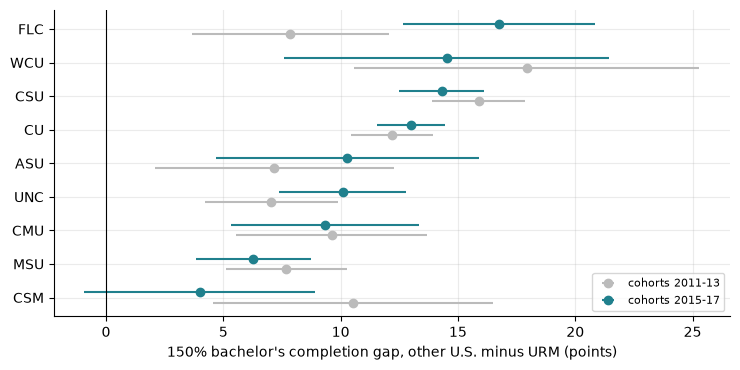

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
order = late["gap (pts)"].sort_values().index
yy = np.arange(len(order))
ax.errorbar(early.loc[order, "gap (pts)"], yy - 0.15, xerr=early.loc[order, "±95% (pts)"],
            fmt="o", color="#BBBBBB", label="cohorts 2011-13")
ax.errorbar(late.loc[order, "gap (pts)"], yy + 0.15, xerr=late.loc[order, "±95% (pts)"],
            fmt="o", color="#20808D", label="cohorts 2015-17")
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(yy, order)
ax.set(xlabel="150% bachelor's completion gap, other U.S. minus URM (points)")
ax.legend(fontsize=8, loc="lower right")
save("11_equity_gaps")

Every four-year board graduates URM students at a lower six-year rate than other
U.S. students. In the 2015-17 cohorts the gap is about 4 to 17 points, and the
intervals for the small boards (Western, Mines, Adams State) are wide. Between the
2011-13 and 2015-17 cohorts there is no common direction. Fort Lewis's gap widened
by about 9 points and Mines's narrowed by about 6.5. Most other changes are within
the intervals.

The comparison is descriptive, not a test of the formula. These cohorts entered
college before HB 20-1366 took effect, so the funding model cannot have caused
their gaps. The point is structural: a board can raise its URM share, and its
funding, while its URM students complete at lower rates, because the formula
measures who enrolls and how everyone fares, not how the gap changes. The
graduation-rate metric includes all students, so closing a gap helps only through
the overall rate. HB 26-1345 adds first-time part-time students to the retention
rate and widens the transfer credit, but the enacted text
([Chapter 391](https://leg.colorado.gov/laws/session-laws/HB26-1345/391/download))
adds no disaggregated outcome metric. Section 10 models the changes that IPEDS
can see.

## 10. HB 26-1345: what the new definitions change

HB 26-1345 ([Session Laws chapter 391](https://leg.colorado.gov/laws/session-laws/HB26-1345/391/download)) applies from FY 2027-28. It keeps
the `D`-ratio arithmetic in sections 2 and 6 word for word, renaming "role and
mission share" to "previous share", but it changes what four metrics measure and
where the data come from. The first cell lists each change and whether IPEDS can
stand in for it.

In [19]:
changes = pd.DataFrame([
    ("Retention adds first-time part-time students", "23-18-302(17)",
     "EF D: RRPTCTA, RET_NMP", "yes: sections 10a-10c"),
    ("Pell-eligible becomes Pell-recipient; concurrent enrollment excluded", "23-18-302(10), (14)",
     "SFA UPGRNTN already counts recipients; no residency or concurrent split", "already the proxy"),
    ("Co-located degree partnership students leave graduation cohorts", "23-18-302(2.5), (8), (9)",
     "none: IPEDS does not flag partnerships", "no"),
    ("Transfer credit after 18 credit hours from any institution", "23-18-302(4)(b)",
     "none: no credit hours or destination at transfer (OM transfer-out is the nearest)", "no"),
    ("Retention and graduation from department data, not IPEDS", "23-18-302(8), (9), (17)",
     "IPEDS becomes proxy-only for every metric", "section 10d (splicing)"),
], columns=["change", "C.R.S.", "IPEDS stand-in", "modelled here"]).set_index("change")
changes

,C.R.S.,IPEDS stand-in,modelled here
change,,,
Retention adds first-time part-time students,23-18-302(17),"EF D: RRPTCTA, RET_NMP",yes: sections 10a-10c
Pell-eligible becomes Pell-recipient; concurrent enrollment excluded,"23-18-302(10), (14)",SFA UPGRNTN already counts recipients; no resi...,already the proxy
Co-located degree partnership students leave graduation cohorts,"23-18-302(2.5), (8), (9)",none: IPEDS does not flag partnerships,no
Transfer credit after 18 credit hours from any institution,23-18-302(4)(b),none: no credit hours or destination at transf...,no
"Retention and graduation from department data, not IPEDS","23-18-302(8), (9), (17)",IPEDS becomes proxy-only for every metric,section 10d (splicing)


### 10a. Inclusive retention

The new retention rate counts first-time students who start part-time alongside
those who start full-time. `EF{y}D` reports both cohorts, so the inclusive rate is
`(RET_NMF + RET_NMP) / (RRFTCTA + RRPTCTA)`. The panel uses the same
consistent-reporter rule as section 5.

In [20]:
rows = []
for y in range(2017, 2025):
    ef = load(f"EF{y}D", f"Fall {y}", ["UNITID", "RRFTCTA", "RET_NMF", "RRPTCTA", "RET_NMP"])
    ef = ef.fillna({"RRPTCTA": 0, "RET_NMP": 0})
    rows += [dict(UNITID=r.UNITID, metric="retention_all", year=y, num=r.RET_NMF + r.RET_NMP,
                  den=r.RRFTCTA + r.RRPTCTA, src="") for r in ef.itertuples()]
inclusive = pd.DataFrame(rows)
inclusive["board"] = inclusive["UNITID"].map(board_of)

years = F.formula_window(T, "retention")
full_time = F.board_series(panel[panel["metric"] == "retention"], years)
all_starts = F.board_series(inclusive, years)
D_incl = D.assign(retention=all_starts.apply(F.d_ratio, axis=1))
print(f"consistent reporters: full-time {F.consistent_reporters(panel[panel['metric'] == 'retention'], years).size}, "
      f"inclusive {F.consistent_reporters(inclusive, years).size}")
pd.DataFrame({f"full-time {years[-1]} %": full_time[years[-1]] * 100,
              f"inclusive {years[-1]} %": all_starts[years[-1]] * 100,
              "level change (pts)": (all_starts[years[-1]] - full_time[years[-1]]) * 100,
              "D full-time": D["retention"], "D inclusive": D_incl["retention"],
              "D change": D_incl["retention"] - D["retention"]}).round(4)

consistent reporters: full-time 18, inclusive 18


,full-time 2023 %,inclusive 2023 %,level change (pts),D full-time,D inclusive,D change
ASU,55.477,54.639,-0.838,0.987,0.992,0.004
CCCS,63.840,57.276,-6.565,1.022,1.020,-0.001
CMU,75.177,74.230,-0.948,1.003,1.005,0.002
CSM,92.975,92.919,-0.057,1.002,1.002,-0.000
CSU,82.910,81.942,-0.969,0.999,0.999,-0.000
CU,83.104,82.074,-1.029,1.004,1.004,-0.000
FLC,62.605,61.629,-0.976,1.008,1.007,-0.002
MSU,70.373,66.579,-3.794,1.033,1.034,0.001
UNC,74.407,74.055,-0.351,1.010,1.010,-0.000
WCU,72.936,72.893,-0.043,1.001,1.002,0.000


Adding part-time starters lowers measured retention most where they are common:
by about 4 points at MSU Denver and 6.6 at CCCS in fall 2023, and by about a point
or less elsewhere. `D` hardly moves, by 0.004 at most, because
the formula scores each board against its own recent past. A level drop that
appears in all four years cancels out. What matters is whether part-time retention
is improving faster or slower than full-time retention.

### 10b. Does IPEDS reproduce the fiscal note?

The [final fiscal note](https://leg.colorado.gov/bill_files/117653/download) applies the part-time change to FY 2025-26 and
reports the reallocation by board (its Table 1, on a $1,034,081,555 base). The cell
below applies the IPEDS inclusive `D` to the same year, scales the share changes
to the fiscal note's base, and compares the two.

In [21]:
FISCAL_NOTE_BASE = 1_034_081_555
# HB 26-1345 final fiscal note (Aug 26, 2026), Table 1
fiscal_note = pd.DataFrame({
    "pell_recipient": {"ASU": -104_573, "CCCS": 1_065_232, "CSM": -28_109, "CSU": -391_139, "FLC": -25_350,
                       "CMU": -61_879, "MSU": -103_817, "CU": -576_029, "UNC": -28_841, "WCU": 254_505},
    "part_time": {"ASU": 12_133, "CCCS": 103_945, "CSM": -18_510, "CSU": 19_583, "FLC": -18_136,
                  "CMU": -4_617, "MSU": 4_493, "CU": -55_707, "UNC": -33_623, "WCU": -9_563},
}).reindex(fund.index)

base = fund["FY 2024-25"]
ipeds_pt = (F.step2_shares(base, D_incl) - F.step2_shares(base, D)) * FISCAL_NOTE_BASE
pt = pd.DataFrame({"IPEDS estimate ($)": ipeds_pt, "fiscal note ($)": fiscal_note["part_time"]})
agree = int((np.sign(pt.iloc[:, 0]) == np.sign(pt.iloc[:, 1])).sum())
print(f"correlation {np.corrcoef(pt.iloc[:, 0], pt.iloc[:, 1])[0, 1]:.2f}; signs agree on {agree} of 10 boards; "
      f"moved ${ipeds_pt.clip(lower=0).sum():,.0f} (IPEDS) vs ${fiscal_note['part_time'].clip(lower=0).sum():,.0f} (fiscal note)")
pt.round(0)

correlation -0.57; signs agree on 5 of 10 boards; moved $58,706 (IPEDS) vs $140,154 (fiscal note)


,IPEDS estimate ($),fiscal note ($)
CU,"-6,689.000",-55707
CSU,849.000,19583
CCCS,"-46,610.000",103945
MSU,"16,689.000",4493
UNC,910.000,-33623
CMU,"16,444.000",-4617
CSM,4.000,-18510
FLC,"-5,407.000",-18136
WCU,"2,289.000",-9563
ASU,"21,521.000",12133


IPEDS does not reproduce the fiscal note. The estimates correlate negatively with
it, agree in sign on half the boards, and move less than half as much money. The
largest disagreement is CCCS: the fiscal note gives it the largest gain, about
$104,000, while IPEDS gives it a loss. That is the section 5 problem again. The
CCCS part-time cohort IPEDS reports fell from 1,430 students in fall 2019 to 626 in
fall 2022, as colleges were reclassified, and the consistent-reporter rule keeps
only the colleges that were never reclassified. The state counts every college's
part-time starters in its own data. For the boards IPEDS measures well, both sources
put the amounts in the tens of thousands of dollars. At that size, modest
differences between IPEDS and state cohorts can flip the sign.

The Pell change cannot be tested at all. The fiscal note differences Pell-recipient
against Pell-eligible allocations, and IPEDS has no Pell-eligible count. The
recipient-based proxy in section 6 is already measuring roughly what the new law
asks for.

### 10c. CCCS sensitivity: can all thirteen colleges be used?

The CCCS estimate rests on the six colleges that report a positive retention
cohort under one definition in every window year. The cell below asks how much
that choice matters. It recomputes CCCS's full-time and inclusive `D`, and the
part-time reallocation, under four alternatives, holding every other board at
its section 10b values:

- **all 13, pooled as reported**: every college's cohort in every year, so
  colleges enter and leave the pool as IPEDS reclassifies them;
- **all 13, invisible colleges held flat**: each college without a full window
  keeps its last cohort that was at least a quarter of its fall 2016 size, at the
  same rate, in every window year. This fixes the composition at all thirteen and
  assumes no change at the colleges IPEDS cannot see;
- **leave one out**: the baseline with each of the six colleges dropped in turn.

In [22]:
cccs_ids = board_of[board_of == "CCCS"].index
cccs_ft = panel[(panel["metric"] == "retention") & panel["UNITID"].isin(cccs_ids)]
cccs_in = inclusive[inclusive["UNITID"].isin(cccs_ids)]
visible = F.consistent_reporters(cccs_in, years)


def pooled_d(frame):
    g = frame[frame["year"].isin(years)].groupby("year")[["num", "den"]].sum().reindex(years)
    return F.d_ratio(g["num"] / g["den"]), g["den"]


def held_flat(frame, min_share=0.25):
    parts = [frame[frame["UNITID"].isin(visible) & frame["year"].isin(years)]]
    held = {}
    for u in sorted(set(cccs_ids) - set(visible)):
        q = frame[(frame["UNITID"] == u) & (frame["year"] <= years[-1])].sort_values("year")
        first = q[q["year"] == 2017]["den"].sum()
        q = q[q["den"] >= min_share * first]
        if q.empty or first == 0:
            continue
        last = q.iloc[-1]
        held[instnm[u]] = (int(last["year"]), int(last["den"]))
        parts.append(pd.DataFrame({"UNITID": u, "year": years, "num": last["num"], "den": last["den"]}))
    return pd.concat(parts), held


def cccs_effect(d_ft, d_in):
    d0 = D.copy()
    d0.loc["CCCS", "retention"] = d_ft
    d1 = D_incl.copy()
    d1.loc["CCCS", "retention"] = d_in
    return (F.step2_shares(base, d1)["CCCS"] - F.step2_shares(base, d0)["CCCS"]) * FISCAL_NOTE_BASE


variants = {
    "consistent reporters (baseline)": (cccs_ft[cccs_ft["UNITID"].isin(visible)], cccs_in[cccs_in["UNITID"].isin(visible)]),
    "all 13, pooled as reported": (cccs_ft, cccs_in),
}
flat_ft, held = held_flat(cccs_ft)
flat_in, _ = held_flat(cccs_in)
variants["all 13, invisible colleges held flat"] = (flat_ft, flat_in)
for u in visible:
    variants[f"drop {instnm[u]}"] = (cccs_ft[cccs_ft["UNITID"].isin(visible.drop(u))],
                                    cccs_in[cccs_in["UNITID"].isin(visible.drop(u))])

rows = []
for label, (ft_frame, in_frame) in variants.items():
    d_ft, _ = pooled_d(ft_frame)
    d_in, cohort = pooled_d(in_frame)
    rows.append({"variant": label, "colleges in window": in_frame.loc[in_frame["year"].isin(years) & (in_frame["den"] > 0), "UNITID"].nunique(),
                 "inclusive cohort, newest year": cohort[years[-1]], "D full-time": d_ft,
                 "D inclusive": d_in, "D gap": d_in - d_ft, "CCCS part-time effect ($)": cccs_effect(d_ft, d_in)})
sensitivity = pd.DataFrame(rows).set_index("variant")
print("held flat at (year, full-time cohort):", ", ".join(f"{k} ({y}, {n:,})" for k, (y, n) in held.items()))
loo = sensitivity.filter(like="drop", axis=0)["CCCS part-time effect ($)"]
print(f"leave-one-out range ${loo.min():,.0f} to ${loo.max():,.0f}; fiscal note ${fiscal_note.loc['CCCS', 'part_time']:,.0f}")
sensitivity.round(4)

held flat at (year, full-time cohort): Arapahoe Community College (2020, 474), Community College of Denver (2017, 430), Front Range Community College (2018, 1,065), Morgan Community College (2018, 83), Pikes Peak State College (2017, 1,052), Pueblo Community College (2017, 233), Red Rocks Community College (2017, 521)
leave-one-out range $-190,446 to $32,568; fiscal note $103,945


,colleges in window,"inclusive cohort, newest year",D full-time,D inclusive,D gap,CCCS part-time effect ($)
variant,,,,,,
consistent reporters (baseline),6,"1,828.000",1.022,1.020,-0.001,"-46,610.039"
"all 13, pooled as reported",9,"1,833.000",1.023,1.023,0.001,"27,790.526"
"all 13, invisible colleges held flat",13,"10,483.000",1.005,1.004,-0.002,"-59,561.211"
drop Colorado Northwestern Community College,5,"1,650.000",1.020,1.021,0.001,"32,567.785"
drop Community College of Aurora,5,"1,153.000",1.020,1.015,-0.005,"-190,446.190"
drop Lamar Community College,5,"1,655.000",1.025,1.022,-0.003,"-99,547.716"
drop Northeastern Junior College,5,"1,534.000",1.022,1.020,-0.002,"-89,795.437"
drop Otero College,5,"1,631.000",1.019,1.020,0.001,"27,710.946"
drop Trinidad State College,5,"1,517.000",1.023,1.022,-0.001,"-35,267.606"


In [23]:
from scipy.optimize import brentq

d_ft0 = sensitivity.loc["consistent reporters (baseline)", "D full-time"]
needed = brentq(lambda d: cccs_effect(d_ft0, d) - fiscal_note.loc["CCCS", "part_time"], 0.9, 1.1)

fall16 = cccs_ft[cccs_ft["year"] == 2017].set_index("UNITID")["den"]
fall16_pt = cccs_in[cccs_in["year"] == 2017].set_index("UNITID")["den"] - fall16
print(f"to reproduce the fiscal note, CCCS inclusive D must be {needed:.4f}: "
      f"{needed - d_ft0:+.4f} against full-time D (baseline gap "
      f"{sensitivity.loc['consistent reporters (baseline)', 'D gap']:+.4f})")
print(f"the six visible colleges were {fall16[visible].sum() / fall16.sum():.0%} of CCCS full-time and "
      f"{fall16_pt[visible].sum() / fall16_pt.sum():.0%} of part-time starters in fall 2016, "
      f"the last year all 13 reported ({fall16.sum():,.0f} and {fall16_pt.sum():,.0f} students)")

to reproduce the fiscal note, CCCS inclusive D must be 1.0243: +0.0029 against full-time D (baseline gap -0.0012)
the six visible colleges were 29% of CCCS full-time and 12% of part-time starters in fall 2016, the last year all 13 reported (5,384 and 5,523 students)


No version of the IPEDS data reproduces the fiscal note. Pooling all thirteen
colleges as reported adds only three colleges inside the window. Arapahoe's single
fall 2019 cohort (1,075 starters, 46% retained) lands in the oldest year, and Red
Rocks and Pueblo contribute a handful of bachelor's seekers. That is enough to flip
the CCCS estimate from -$46,610 to +$27,790. It is the reclassification artifact
from section 5 once more: a large, low-retention cohort that appears in the oldest
year only raises `D` without any change in students' outcomes.

Holding the seven invisible colleges flat fixes the composition at all thirteen,
which pulls both `D` ratios toward one (full-time from 1.022 to 1.005). The
inclusive ratio still sits below the full-time one, so CCCS still loses, about
$59,600. Dropping one visible college at a time gives anything from -$190,446
(without Aurora, the largest part-time cohort among the six) to +$32,568. The sign
of the estimate depends on which single college is included.

Reproducing the fiscal note's +$103,945 would need CCCS's inclusive `D` to sit
about 0.003 above its full-time `D`. Every variant here leaves the two within about
0.001 of each other or puts the inclusive ratio below. The visible colleges were 29%
of CCCS full-time starters and only 12% of part-time starters in fall 2016, the last
year all thirteen reported. The state's figure plausibly reflects part-time
retention trends at the large colleges IPEDS stopped measuring, such as Front
Range, Pikes Peak, and Red Rocks. That is a question for SURDS, not IPEDS. Within IPEDS, the defensible
statement is a bound: the data cannot even fix the sign of CCCS's part-time effect.

### 10d. The splicing trap

When the definitions change, the state can recompute all four window years under
the new rules, or let new-definition years enter the window one at a time. The act
does not say which. Splicing puts a definitional change into the numerator of `D`
in the same way IPEDS reclassification does. The cell below compares the two for
the first year a splice would occur: three full-time-only years plus one inclusive
year.

In [24]:
spliced = full_time.copy()
spliced[years[-1]] = all_starts[years[-1]]
D_splice = D.assign(retention=spliced.apply(F.d_ratio, axis=1))
splice_dollars = (F.step2_shares(base, D_splice) - F.step2_shares(base, D)) * FISCAL_NOTE_BASE
splice = pd.DataFrame({"D recomputed": D_incl["retention"], "D spliced": D_splice["retention"],
                       "recomputed ($)": ipeds_pt, "spliced ($)": splice_dollars})
print(f"moved between boards: recomputed ${ipeds_pt.clip(lower=0).sum():,.0f}, "
      f"spliced ${splice_dollars.clip(lower=0).sum():,.0f}")
splice.round(4)

moved between boards: recomputed $58,706, spliced $984,063


,D recomputed,D spliced,recomputed ($),spliced ($)
CU,1.004,1.001,"-6,688.933","390,790.488"
CSU,0.999,0.996,848.802,"284,512.639"
CCCS,1.020,0.994,"-46,610.039","-894,049.980"
MSU,1.034,1.018,"16,688.583","-90,013.042"
UNC,1.010,1.009,910.035,"101,189.913"
CMU,1.005,1.000,"16,444.028","54,818.887"
CSM,1.002,1.002,4.317,"60,677.528"
FLC,1.007,1.004,"-5,407.282","22,852.559"
WCU,1.002,1.001,"2,289.403","40,402.537"
ASU,0.992,0.984,"21,521.086","28,818.471"


Splicing moves about $984,000 between boards, against $59,000 for a consistent
recomputation, roughly seventeen times as much. That is almost as much as all eight
metrics together moved in FY 2025-26 ($1.11 million, section 7). CCCS alone would
lose about $894,000 and MSU Denver about $90,000, simply because they enrol the
most part-time students, whose lower retention would read as a decline. CU and CSU
would gain for the same reason in reverse. None of this would reflect any change in
students' outcomes. A study of FY 2027-28 should therefore check CDHE's data
definitions for how the window is built before treating any board's change as
performance.

### 10e. Definitions versus performance

The fiscal note's two columns can be set beside the performance reallocation from
section 7.

In [25]:
compare = pd.DataFrame({
    "FY 2025-26 performance": moved["moved"],
    "Pell-recipient switch": fiscal_note["pell_recipient"],
    "part-time retention": fiscal_note["part_time"],
})
compare["both definition changes"] = compare["Pell-recipient switch"] + compare["part-time retention"]
summary = compare.clip(lower=0).sum().rename("moved between boards ($)")
print(summary.map("{:,.0f}".format).to_string())
compare.round(0)

FY 2025-26 performance     1,109,968
Pell-recipient switch      1,319,737
part-time retention          140,154
both definition changes    1,414,119


,FY 2025-26 performance,Pell-recipient switch,part-time retention,both definition changes
CU,"-71,378.000",-576029,-55707,-631736
CSU,"-446,641.000",-391139,19583,-371556
CCCS,"-89,913.000",1065232,103945,1169177
MSU,"882,841.000",-103817,4493,-99324
UNC,"-174,294.000",-28841,-33623,-62464
CMU,"-66,862.000",-61879,-4617,-66496
CSM,"158,956.000",-28109,-18510,-46619
FLC,"68,171.000",-25350,-18136,-43486
WCU,"-115,852.000",254505,-9563,244942
ASU,"-145,028.000",-104573,12133,-92440


The two definitional changes would move about $1.41 million between boards, more
than the $1.11 million that a full year of performance moved in FY 2025-26, with no
change in what students did. Almost all of it comes from the Pell switch
($1.32 million), and almost all of it goes to CCCS and Western. The bases differ
($1.034 billion in the fiscal note, $1.246 billion here), so the comparison is about
scale, not exact dollars. The lesson is still clear: in this formula, how a metric
is defined can matter as much as how institutions perform on it.

## Takeaways

- **The formula is reproducible from public data, roughly.** IPEDS plus CDHE's FTE
  series recover the pattern of FY 2025-26 increases (correlation 0.82) and of the
  FY 2026-27 request, a year the model was not tuned on (0.63). Both are unlikely
  to be chance (exact permutation p = 0.003 and 0.028) and beat every placebo
  window, but with ten boards the strength of the fit is imprecise: the FY 2026-27
  interval reaches zero.
- **It moves little money.** About $1.1 million of $1.25 billion in FY 2025-26, and
  about $1.5 million in the FY 2026-27 request. The incentive at the margin is small.
- **Performance is relative and front-loaded.** A board gains by improving faster than
  the others, the reward for a lasting gain fades within three years, and the higher
  base persists.
- **IPEDS cannot see the community colleges correctly.** Reclassification removes most
  of the CCCS retention cohort from IPEDS, which is why the state is moving to SURDS.
- **Access is rewarded; gaps are not.** Forty percent of the weight rewards enrollment
  shares, and no metric rewards closing completion gaps.
- **Under HB 26-1345, definitions move as much money as performance.** The fiscal note's
  Pell and part-time changes reallocate about $1.41 million. Splicing old and new
  definitions in one window would move nearly $1 million more, with no change in
  student outcomes.

## Exercises

1. Hold the FY 2025-26 data fixed and change the weights. What weighting would
   have given MSU Denver the smallest increase instead of the largest?
2. Rebuild `D` using `GR200` (200% graduation) in place of the 150% rate. Which boards
   would gain, and why might a formula prefer the longer window for two-year colleges?
3. Use `EF{y}C` (residence of first-time students) to restrict the URM proxy to
   Colorado residents. Does the reconstruction improve?
4. Compute section 9's gaps for Pell recipients with `GR{y}_PELL_SSL`. Is the Pell gap
   larger or smaller than the URM gap on each board?
5. When SFA 2024-25 is published, rerun section 7's FY 2026-27 test with the Pell
   window caught up. Does the fit improve, and do MSU Denver and UNC change sign?
6. Repeat section 10c with two and three new-definition years in the window. How
   long does a splice keep distorting `D`, and does the distortion change sign?
7. Section 10c holds the invisible CCCS colleges flat. Replace that assumption with
   each college's own 2017-2019 trend, extrapolated. How far must the invisible
   colleges' part-time retention rise, relative to full-time, to reach the fiscal
   note's +$103,945?

## Appendix: data for the dashboard formula lab

The Colorado panel's formula lab and coverage panel read the objects built above,
so the dashboard and this notebook cannot disagree. The cell writes
`dashboard/data/colorado_formula.json` when the notebook runs inside the parent
repository and checks that the exported window series reproduce the `D` ratios
of section 6 (FY 2025-26) and section 7's second test (FY 2026-27) exactly. It
also carries section 7's fit checks for CDHE's weights, which the lab shows
beside the results it recomputes for any weights.

In [26]:
import datetime as dt

LAB = ["retention", "grad100", "grad150", "urm_share", "pell_share", "credentials"]
COHORT_YEARS = list(range(2017, 2025))


def status(sub, unitid, yrs):
    q = sub[(sub["UNITID"] == unitid) & sub["year"].isin(yrs)]
    if q.empty:
        return "not reported"
    if unitid in F.consistent_reporters(sub, yrs):
        return "used"
    if q["src"].nunique() > 1 if "src" in q else False:
        return "definition changed"
    if len(q) < len(yrs) or q["num"].isna().any():
        return "missing year"
    return "zero cohort"


def num(v, places=6):
    return None if pd.isna(v) else round(float(v), places)


def strength_out(fy_start):
    st = strength_num[fy_start]
    return {
        "r": num(st["r"], 4), "p": num(st["p"], 6), "permutations": st["permutations"],
        "fisher": [num(v, 4) for v in st["fisher"]], "bootstrap": [num(v, 4) for v in st["bootstrap"]],
        "leaveOneOut": {b: num(v, 4) for b, v in st["leaveOneOut"].items()},
        "placebo": [num(v, 4) for v in st["placebo"]], "noiseR": [num(v, 4) for v in st["noiseR"]],
        "noisePct": {b: [num(v, 4) for v in iv] for b, iv in st["noisePct"].items()}, "draws": st["draws"],
    }


def export_year(fy_start, d_check, target, target_kind, pct_check):
    # Window series for one fiscal year, checked against the D used in the notebook.
    ret_years = F.formula_window(fy_start, "retention")
    windows, series, reporters, lagged = {}, {}, {}, []
    for m in LAB:
        sub = panel[panel["metric"] == m]
        yrs = F.formula_window(fy_start, m)
        if yrs[-1] > sub["year"].max():
            yrs = [y - 1 for y in yrs]
            lagged.append(m)
        windows[m] = yrs
        series[m] = F.board_series(sub, yrs)
        keep = F.consistent_reporters(sub, yrs)
        reporters[m] = sub[sub["UNITID"].isin(keep)].groupby("board")["UNITID"].nunique()
        assert (series[m].apply(F.d_ratio, axis=1) - d_check[m]).abs().max() < 1e-12, (fy_start, m)
    fte_years = [F.fiscal_year_label(y) for y in F.formula_window(fy_start, "resident_fte")]
    series["resident_fte"] = fte.loc[fund.index, fte_years]
    windows["resident_fte"] = fte_years
    incl = F.board_series(inclusive, ret_years)
    cov_metrics = {"retention": panel[panel["metric"] == "retention"], "retention_all": inclusive,
                   **{m: panel[panel["metric"] == m] for m in LAB[1:]}}
    cov_windows = {"retention_all": ret_years, **windows}
    base_fy = fund[F.fiscal_year_label(fy_start - 1)]
    return {
        "fiscalYear": F.fiscal_year_label(fy_start), "baseYear": F.fiscal_year_label(fy_start - 1),
        "target": target_kind, "windows": {m: [str(y) for y in w] for m, w in windows.items()},
        "lagged": lagged, "retentionYears": ret_years, "strength": strength_out(fy_start),
        "boards": {b: {
            "base": float(base_fy[b]), "target": float(target[b]),
            "series": {m: [num(v) for v in series[m].loc[b]] for m in series},
            "retentionInclusive": [num(v) for v in incl.loc[b]],
            "reporters": {m: int(reporters[m].get(b, 0)) for m in LAB},
            "notebookPct": num(pct_check[b], 4),
        } for b in fund.index},
        "status": {str(int(u)): {m: status(sub, u, cov_windows[m]) for m, sub in cov_metrics.items()}
                   for u in board_of.index},
    }


years_out = [
    export_year(T, D, fund[F.fiscal_year_label(T)], "actual", pred),
    export_year(T2, D2, base2 + request.reindex(base2.index), "request", rebuilt / base2 * 100),
]

ft_den = panel[panel["metric"] == "retention"].pivot_table(index="UNITID", columns="year", values="den")
all_den = inclusive.pivot_table(index="UNITID", columns="year", values="den")
units = []
for u, b in sorted(board_of.items(), key=lambda kv: (kv[1], str(instnm.get(kv[0], kv[0])))):
    units.append({
        "unitid": int(u), "name": instnm.get(u, str(u)), "board": b,
        "ftCohort": [None if pd.isna(v) else int(v) for v in ft_den.reindex(index=[u], columns=COHORT_YEARS).iloc[0]],
        "allCohort": [None if pd.isna(v) else int(v) for v in all_den.reindex(index=[u], columns=COHORT_YEARS).iloc[0]],
    })

lab = {
    "meta": {
        "built": dt.date.today().isoformat(),
        "notebook": "ipeds-mining/notebooks/" + "11_colorado_performance_funding.ipynb",
        "cohortYears": COHORT_YEARS, "fiscalNoteBase": FISCAL_NOTE_BASE,
        "sources": {
            "definitions": "https://cdhe.colorado.gov/sites/highered/files/Colorado_Performance_Funding_Overview_and_Data_Definitions_2025_26_1.pdf",
            "jbcMemo": "https://content.leg.colorado.gov/sites/default/files/hedainfo-09-09-2025.pdf",
            "jbcBriefing": "https://content.leg.colorado.gov/sites/default/files/fy2026-27_hedbrf.pdf",
            "fiscalNote": "https://leg.colorado.gov/bill_files/117653/download",
            "sessionLaw": "https://leg.colorado.gov/laws/session-laws/HB26-1345/391/download",
            "ipeds": "https://nces.ed.gov/ipeds/use-the-data",
        },
    },
    "weights": F.WEIGHTS,
    "metrics": {m: F.METRICS[m] for m in F.WEIGHTS},
    "boards": [{"id": b, "name": names[b], "fiscalNote": {k: int(fiscal_note.loc[b, k]) for k in fiscal_note}}
               for b in fund.index],
    "years": years_out,
    "units": units,
    "cccs": {
        "fiscalYear": F.fiscal_year_label(T),
        "sensitivity": [{"variant": k, **{c: num(v, 4) for c, v in r.items()}} for k, r in sensitivity.iterrows()],
        "neededGap": num(needed - d_ft0, 4), "baselineGap": num(sensitivity.iloc[0]["D gap"], 4),
        "visibleShareFt": num(fall16[visible].sum() / fall16.sum(), 4),
        "visibleSharePt": num(fall16_pt[visible].sum() / fall16_pt.sum(), 4),
        "fall16Ft": int(fall16.sum()), "fall16Pt": int(fall16_pt.sum()),
        "visible": [int(u) for u in visible],
    },
}
out = Path("../../dashboard/data")
if out.is_dir():
    (out / "colorado_formula.json").write_text(json.dumps(lab, separators=(",", ":")) + "\n")
    print(f"wrote {out / 'colorado_formula.json'}: {len(lab['boards'])} boards, "
          f"{', '.join(y['fiscalYear'] for y in years_out)}, {len(units)} IPEDS units")
else:
    print("not inside the parent repository; skipped the dashboard export")

wrote ../../dashboard/data/colorado_formula.json: 10 boards, FY 2025-26, FY 2026-27, 25 IPEDS units
